In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## 1. Overview

This notebook performs exploratory data analysis on a student performance dataset to investigate the relationships among activity habits, stress levels, and GPA.

In [53]:
df = pd.read_csv("student_lifestyle_dataset.csv")

In [54]:
df.head(10)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High
5,6,6.0,2.1,8.0,0.3,7.6,2.85,Moderate
6,7,8.0,0.7,5.3,5.7,4.3,3.08,High
7,8,8.4,1.8,5.6,3.0,5.2,3.20,High
8,9,5.2,3.6,6.3,4.0,4.9,2.82,Low
9,10,7.7,0.7,9.8,4.5,1.3,2.76,Moderate


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   str    
dtypes: float64(6), int64(1), str(1)
memory usage: 125.1 KB


In [56]:
df.shape

(2000, 8)

In [57]:
df.duplicated().sum()

np.int64(0)

In [58]:
df.isnull().sum()

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

Dataset contains neither duplicate records nor missing values.

In [59]:
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


- GPA ranges from 2,24 to 4.00 with average 3.116 and relative small standard 0.3.
- Student studies about average 7.4758 hour a day, from 5 to 10 hour with standard 1.424  
- Note that sum of mean of all activities above approximate 24 hours, it means that almost all activities which student do every day belongs to one of these activities and if they spend more time for one activity, they must decline time for other activities.
- Someone spend 13 hours for physical activity in one day, probably there are some outliers exist in this dataset.

In [60]:
df["Stress_Level"].unique()

<StringArray>
['Moderate', 'Low', 'High']
Length: 3, dtype: str

In [61]:
df["Stress_Level"].value_counts()

Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64

In general, dataset contains three levels of stress (high, moderate and low) with the number of students tends to increase progressively with higher stress level.

## 2. Visualize data

Remove identifier column Student_ID 

In [62]:
eda_df = df.drop(columns=["Student_ID"])

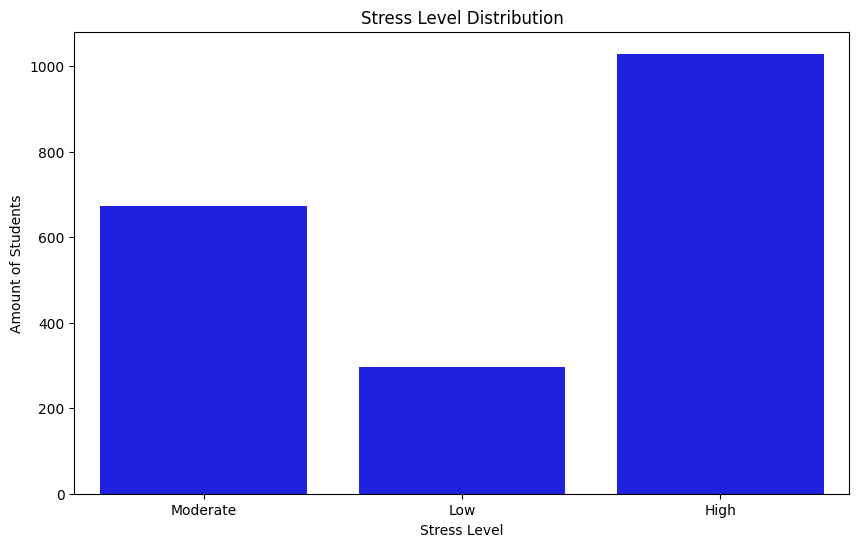

In [63]:
## Visualize Stress Level Distribution
plt.figure(figsize=(10,6))

sns.countplot(data=eda_df, x="Stress_Level", color = 'blue')

plt.title("Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Amount of Students")
plt.show()

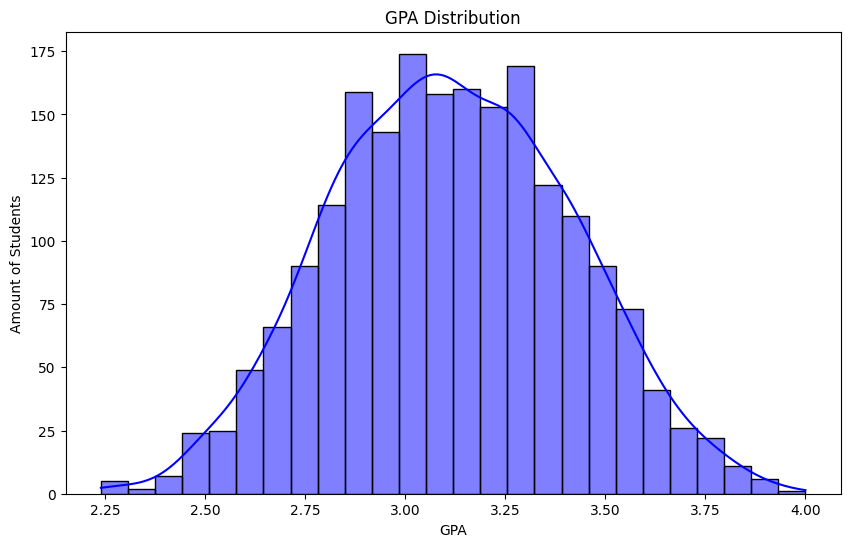

In [64]:
## Visualize GPA Distribution
plt.figure(figsize=(10,6))

sns.histplot(data=eda_df, x="GPA", kde=True, color='blue')

plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Amount of Students")
plt.show()

The GPA is approximately normally distributed 

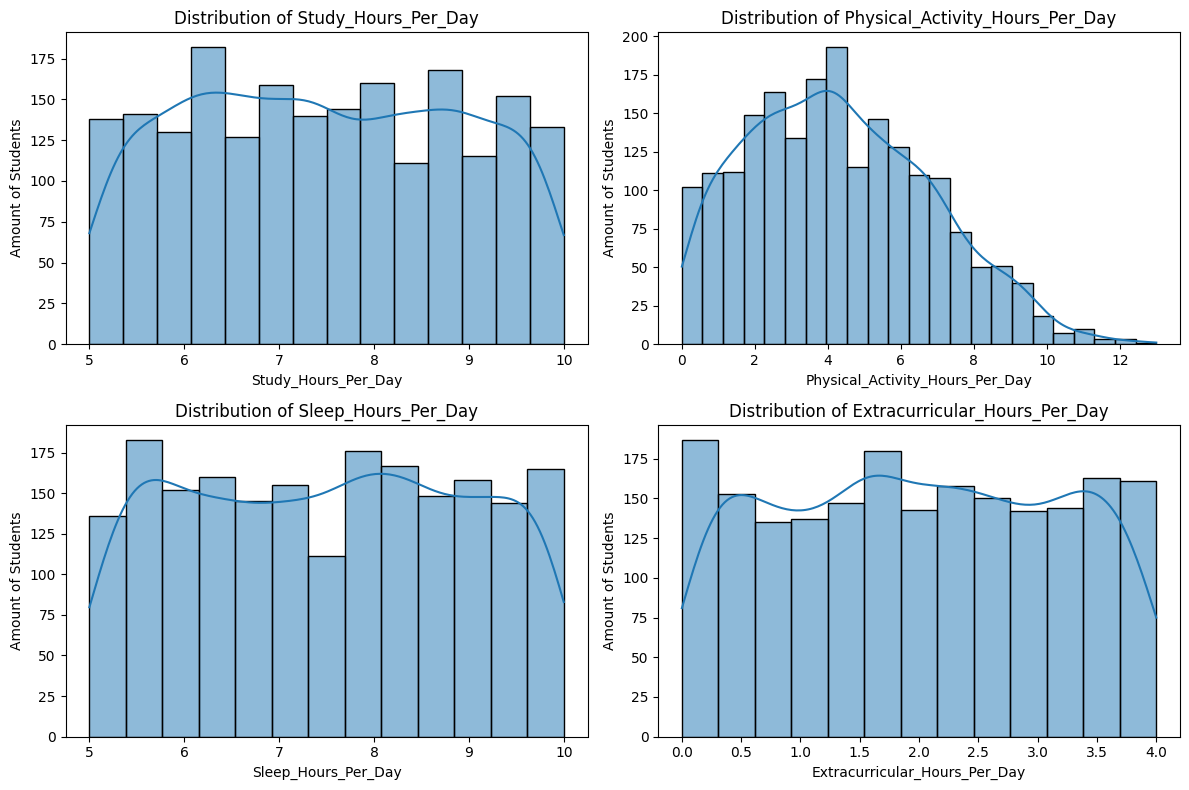

In [65]:
## Visualize Time for Activities on day Distributions
cols = ["Study_Hours_Per_Day", "Physical_Activity_Hours_Per_Day", "Sleep_Hours_Per_Day", "Extracurricular_Hours_Per_Day"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=eda_df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Amount of Students")

plt.tight_layout()
plt.show()

##  3. Correlation Analysis

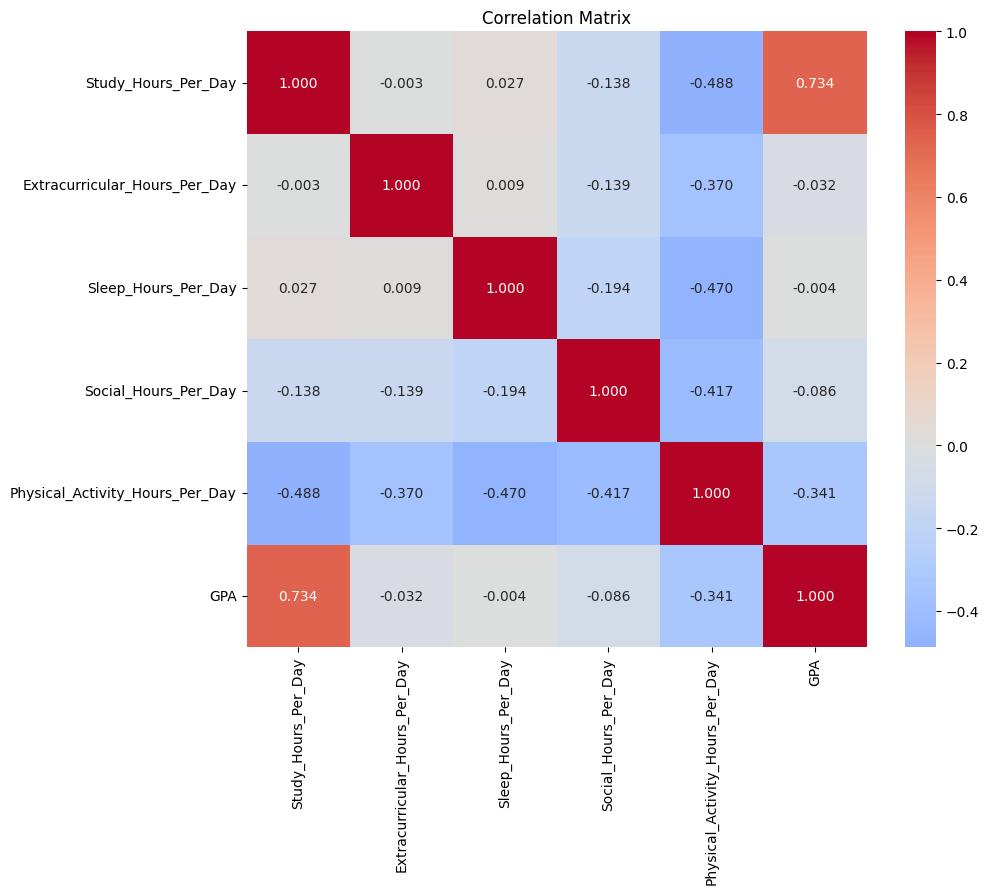

In [66]:
corr_matrix = eda_df.corr(
    numeric_only=True
)


plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

Study Hours Per Day shows the strongest positive correlation with GPA.

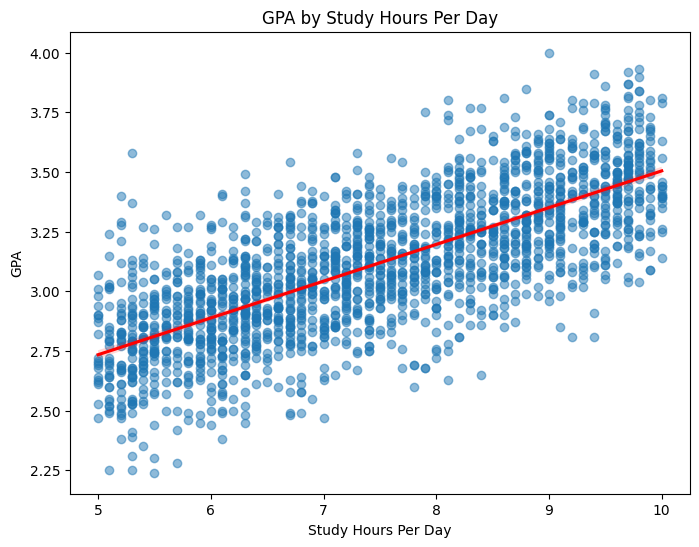

In [67]:
## Visualize GPA by Study Hours Per Day
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='Study_Hours_Per_Day',
    y='GPA',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.title('GPA by Study Hours Per Day')
plt.xlabel('Study Hours Per Day')
plt.ylabel('GPA')

plt.show()

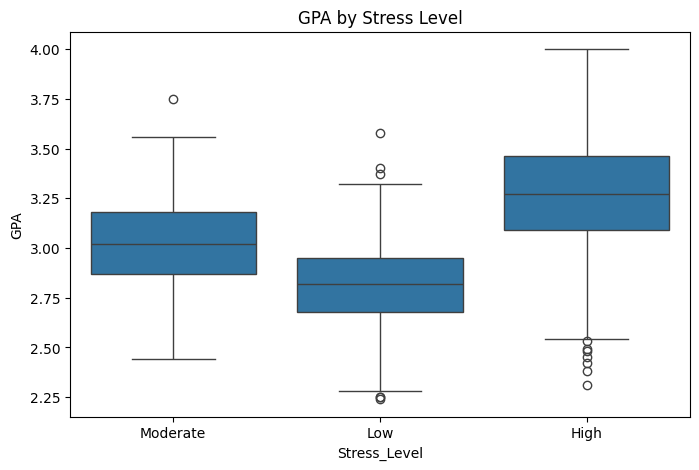

In [68]:
## Visualize GPA by Stress Level
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Stress_Level",
    y="GPA"
)

plt.title("GPA by Stress Level")

plt.show()

Text(0.5, 1.0, 'GPA by Stress Level and Study Hours Per Day')

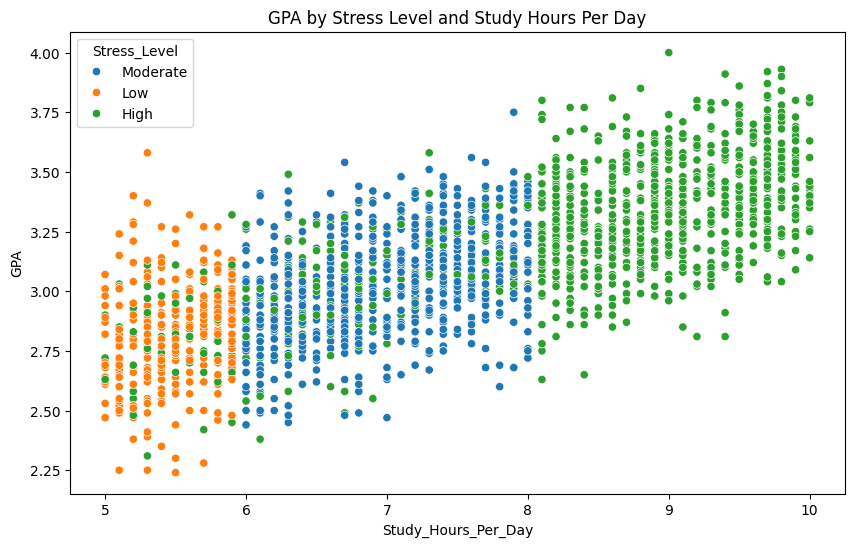

In [69]:
## Visualize GPA by Study Hours Per Day and Stress Level
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=eda_df["Study_Hours_Per_Day"],
    y=eda_df["GPA"],
    hue=eda_df["Stress_Level"],
)

plt.title("GPA by Stress Level and Study Hours Per Day")

In general, these plot indicates a positive relationship among stress levels, study hours and GPA. Students with higher stress levels tend to spend more time studying and generally achieve higher GPAs. However, stress itself may not be the direct cause of improved academic performance. Instead, study hours could be a confounding factor influencing both stress level and GPA. Moreover, considerable overlap among stress groups suggests that stress level alone is insufficient to explain variations in academic performance.